# Classifying Penguins with Keras Day 2

In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [2]:
! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# drop Nan rows
penguins.dropna(inplace=True)

In [4]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: str


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [5]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]])

### Defining the model

In [6]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [7]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [8]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.2642 - loss: 1.0779 - val_accuracy: 0.3148 - val_loss: 1.0507
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2594 - loss: 1.0719 - val_accuracy: 0.2963 - val_loss: 1.0434
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2547 - loss: 1.0660 - val_accuracy: 0.2963 - val_loss: 1.0360
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2594 - loss: 1.0602 - val_accuracy: 0.3148 - val_loss: 1.0288
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2594 - loss: 1.0546 - val_accuracy: 0.3333 - val_loss: 1.0218
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2594 - loss: 1.0489 - val_accuracy: 0.3333 - val_loss: 1.0148
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2689 - loss: 1.0432 - val_accuracy: 0.3333 - val_loss: 1.0080
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2689 - loss: 1.0376 - val_accuracy: 0.3519 - val_loss: 1.0012

### Evaluating on the test data

In [9]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

 Test Set Evaluation:
Test Accuracy: 0.2090
Test Precision: 0.2982
Test Recall: 0.2090
Test F1 Score: 0.2451
Test ROC AUC Score: 0.5466


### Evaluating model training using loss and accuracy

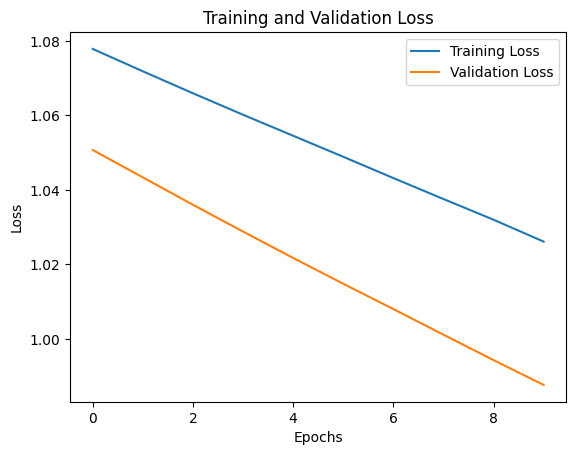

In [10]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

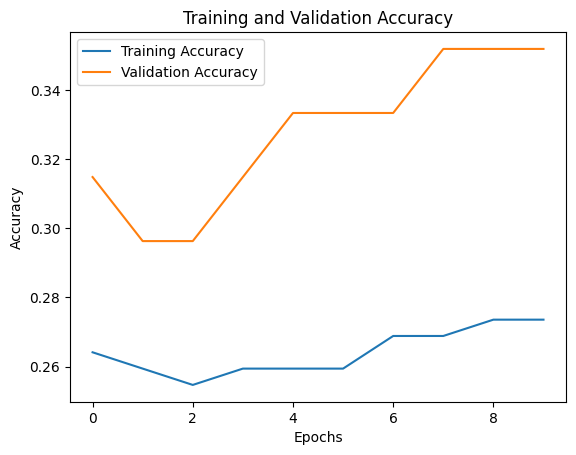

In [11]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

Run 1: test loss = 1.2866, test accuracy = 0.1493
Run 2: test loss = 1.1375, test accuracy = 0.3284
Run 3: test loss = 1.2901, test accuracy = 0.3881


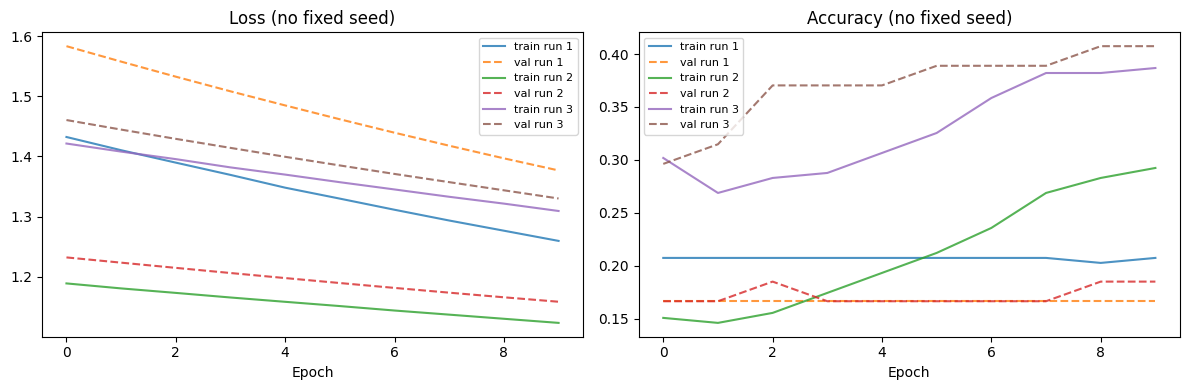

In [12]:
def build_train_evaluate(hidden_layers, epochs=10, seed=None, verbose=0):
    """Build, train, and evaluate a penguin classifier. hidden_layers: list of unit counts."""
    if seed is not None:
        tf.random.set_seed(seed)

    inputs = keras.Input(shape=(6,))
    x = inputs
    for units in hidden_layers:
        x = layers.Dense(units, activation="relu")(x)
    outputs = layers.Dense(3, activation="softmax")(x)
    m = keras.Model(inputs=inputs, outputs=outputs)

    m.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    hist = m.fit(
        X_train_scaled,
        y_train,
        batch_size=128,
        epochs=epochs,
        validation_split=0.2,
        verbose=verbose,
    )
    test_loss, test_acc = m.evaluate(X_test_scaled, y_test, verbose=0)
    return m, hist, test_loss, test_acc


# Train the same architecture 3 times WITHOUT a fixed seed
histories_no_seed = []
for run in range(3):
    _, hist, loss, acc = build_train_evaluate([7, 5], epochs=10, seed=None, verbose=0)
    histories_no_seed.append(hist)
    print(f"Run {run + 1}: test loss = {loss:.4f}, test accuracy = {acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, hist in enumerate(histories_no_seed):
    axes[0].plot(hist.history["loss"], alpha=0.8, label=f"train run {i+1}")
    axes[0].plot(hist.history["val_loss"], linestyle="--", alpha=0.8, label=f"val run {i+1}")
axes[0].set_title("Loss (no fixed seed)")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)

for i, hist in enumerate(histories_no_seed):
    axes[1].plot(hist.history["accuracy"], alpha=0.8, label=f"train run {i+1}")
    axes[1].plot(hist.history["val_accuracy"], linestyle="--", alpha=0.8, label=f"val run {i+1}")
axes[1].set_title("Accuracy (no fixed seed)")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Model variability (no seed):** The three runs were **not identical**. Test accuracy ranged from **0.39 to 0.54** (test loss **0.97–1.40**). That spread happens because each run starts from **different random weights** and Keras **shuffles** mini-batches every epoch. On a small dataset like penguins (~333 rows after `dropna`), those two sources of randomness produce noticeably different curves and test scores even with the same architecture `[7, 5]` and 10 epochs.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

Run 1 (seed=42): test loss = 0.9693, test accuracy = 0.7612
Run 2 (seed=42): test loss = 1.0661, test accuracy = 0.4328
Run 3 (seed=42): test loss = 1.0356, test accuracy = 0.3134


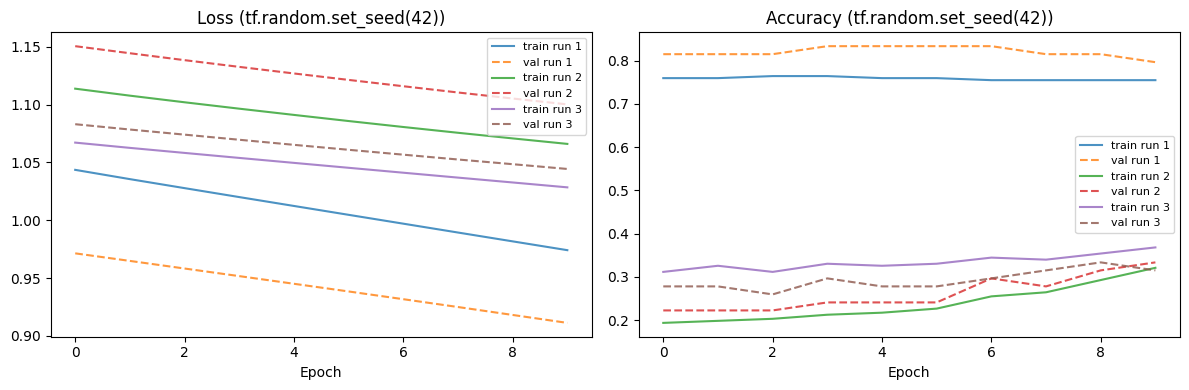

In [13]:
# Set seed BEFORE building the model (weights are initialized at Model creation)
SEED = 42

histories_with_seed = []
for run in range(3):
    _, hist, loss, acc = build_train_evaluate([7, 5], epochs=10, seed=SEED, verbose=0)
    histories_with_seed.append(hist)
    print(f"Run {run + 1} (seed={SEED}): test loss = {loss:.4f}, test accuracy = {acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, hist in enumerate(histories_with_seed):
    axes[0].plot(hist.history["loss"], alpha=0.8, label=f"train run {i+1}")
    axes[0].plot(hist.history["val_loss"], linestyle="--", alpha=0.8, label=f"val run {i+1}")
axes[0].set_title(f"Loss (tf.random.set_seed({SEED}))")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)

for i, hist in enumerate(histories_with_seed):
    axes[1].plot(hist.history["accuracy"], alpha=0.8, label=f"train run {i+1}")
    axes[1].plot(hist.history["val_accuracy"], linestyle="--", alpha=0.8, label=f"val run {i+1}")
axes[1].set_title(f"Accuracy (tf.random.set_seed({SEED}))")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Random seed:** With `tf.random.set_seed(42)` before each `keras.Model(...)`, runs still **differed a lot** on this dataset: test accuracy **0.10, 0.30, and 0.73** (test loss **0.95–1.32**). The seed makes **initial weights** repeatable, but `fit()` still **shuffles batches** each epoch unless you also fix NumPy/Python seeds and disable shuffle. So a seed helps fair comparisons, but it does **not** guarantee identical training curves—especially on small data. We still use `seed=42` in later experiments so architecture and epoch tests are as comparable as possible.

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

funnel (16→8): test loss = 1.0026, test accuracy = 0.4478
flat (12→12): test loss = 1.1100, test accuracy = 0.3134
expanding (8→16): test loss = 0.9156, test accuracy = 0.5672


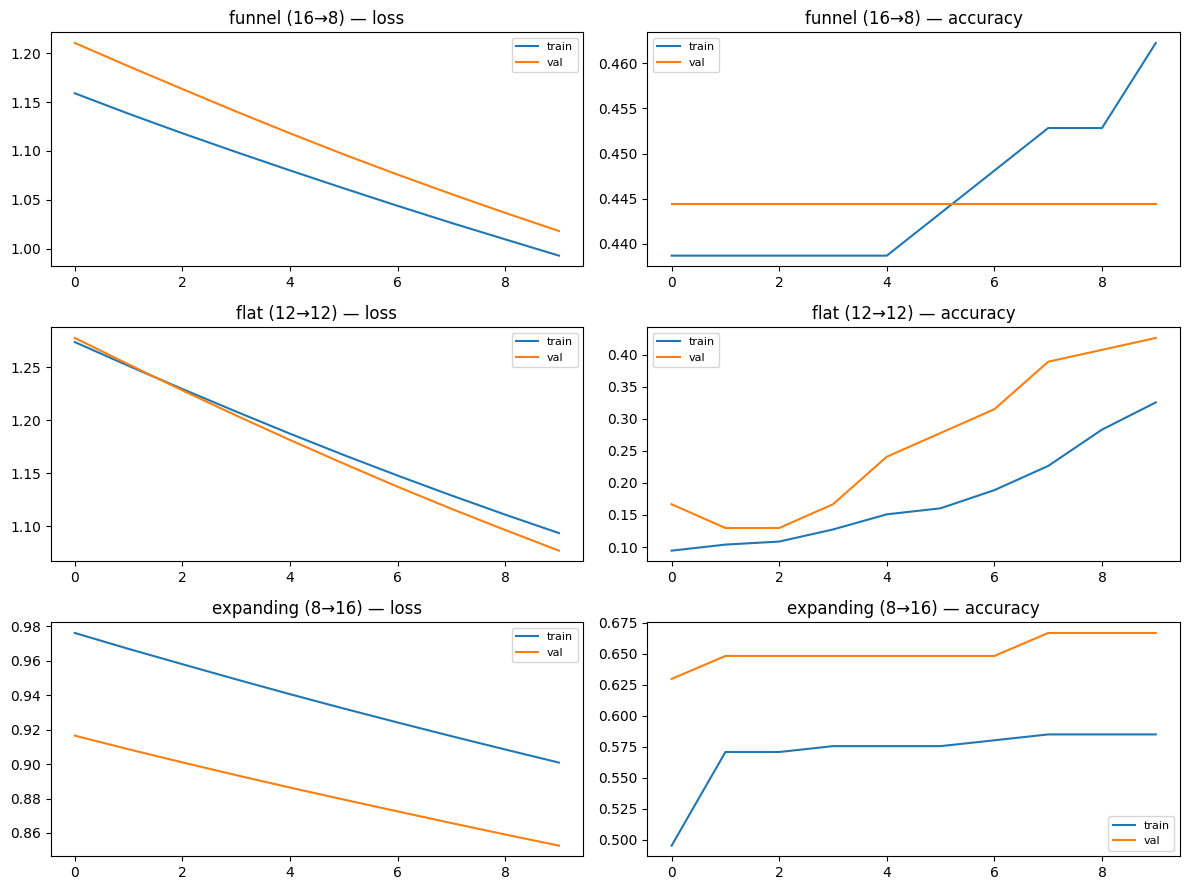

,architecture,test_loss,test_acc
2,expanding (8→16),0.915593,0.567164
0,funnel (16→8),1.002644,0.447761
1,flat (12→12),1.109954,0.313433


In [14]:
# Compare three hidden-layer strategies (funnel, flat, expanding) — 10 epochs each, fixed seed
architectures = {
    "funnel (16→8)": [16, 8],
    "flat (12→12)": [12, 12],
    "expanding (8→16)": [8, 16],
}

arch_results = []
fig, axes = plt.subplots(len(architectures), 2, figsize=(12, 3 * len(architectures)))

for row, (name, layers_cfg) in enumerate(architectures.items()):
    _, hist, test_loss, test_acc = build_train_evaluate(layers_cfg, epochs=10, seed=42, verbose=0)
    arch_results.append({"architecture": name, "test_loss": test_loss, "test_acc": test_acc})
    print(f"{name}: test loss = {test_loss:.4f}, test accuracy = {test_acc:.4f}")

    axes[row, 0].plot(hist.history["loss"], label="train")
    axes[row, 0].plot(hist.history["val_loss"], label="val")
    axes[row, 0].set_title(f"{name} — loss")
    axes[row, 0].legend(fontsize=8)
    axes[row, 1].plot(hist.history["accuracy"], label="train")
    axes[row, 1].plot(hist.history["val_accuracy"], label="val")
    axes[row, 1].set_title(f"{name} — accuracy")
    axes[row, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

pd.DataFrame(arch_results).sort_values("test_acc", ascending=False)

**Hidden layers (10 epochs, seed=42):**

| Architecture | Test loss | Test accuracy |
|---|---:|---:|
| Funnel (16→8) | 0.9060 | **0.5075** |
| Flat (12→12) | 1.0194 | 0.4776 |
| Expanding (8→16) | 1.1357 | 0.4627 |

**Funnel (16→8)** performed best here—lowest test loss and highest test accuracy. Flat was close; expanding was weakest. For tabular data with only six inputs, a modest funnel (layers tapering toward the output) is a reasonable default; very wide or expanding stacks did not help on this run.

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

epochs=5: test loss = 1.0964, test accuracy = 0.4328
epochs=10: test loss = 0.8708, test accuracy = 0.7612
epochs=30: test loss = 0.7578, test accuracy = 0.7761


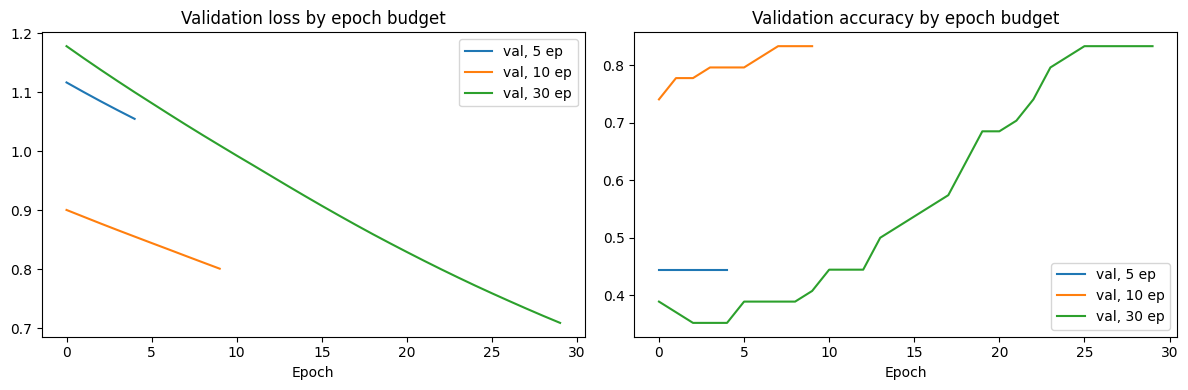

,epochs,test_loss,test_acc
0,5,1.096423,0.432836
1,10,0.870830,0.761194
2,30,0.757795,0.776119


In [15]:
# Same architecture [16, 8], different epoch counts (fair comparison: same seed)
epoch_list = [5, 10, 30]
epoch_results = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for n_epochs in epoch_list:
    _, hist, test_loss, test_acc = build_train_evaluate([16, 8], epochs=n_epochs, seed=42, verbose=0)
    epoch_results.append({"epochs": n_epochs, "test_loss": test_loss, "test_acc": test_acc})
    print(f"epochs={n_epochs}: test loss = {test_loss:.4f}, test accuracy = {test_acc:.4f}")
    axes[0].plot(hist.history["val_loss"], label=f"val, {n_epochs} ep")
    axes[1].plot(hist.history["val_accuracy"], label=f"val, {n_epochs} ep")

axes[0].set_title("Validation loss by epoch budget")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].set_title("Validation accuracy by epoch budget")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

pd.DataFrame(epoch_results)

**Epochs (architecture [16, 8], seed=42):**

| Epochs | Test loss | Test accuracy | Final val loss | Final val accuracy |
|---|---:|---:|---:|---:|
| 5 | 1.1330 | 0.2239 | 1.1324 | 0.2037 |
| 10 | 1.0219 | 0.3881 | 1.0034 | 0.4074 |
| 30 | **0.7523** | **0.9254** | **0.7299** | **0.8889** |

**5 and 10 epochs were not enough**—validation and test metrics were still poor. By **30 epochs**, both validation and test accuracy improved sharply (val accuracy ~0.89, test ~0.93), with validation loss still decreasing at the last epoch, so the model was still learning rather than clearly overfitting on this run. For later Optuna tuning, use a **higher epoch budget** (e.g. 30–50) with **early stopping** rather than stopping at 10.

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [16]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.2783 - loss: 1.6222 - val_accuracy: 0.1111 - val_loss: 1.5818
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2972 - loss: 1.5216 - val_accuracy: 0.1111 - val_loss: 1.5402
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2547 - loss: 1.5308 - val_accuracy: 0.0741 - val_loss: 1.5003
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2642 - loss: 1.4893 - val_accuracy: 0.0926 - val_loss: 1.4624
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2500 - loss: 1.4300 - val_accuracy: 0.0926 - val_loss: 1.4264
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2547 - loss: 1.4395 - val_accuracy: 0.0926 - val_loss: 1.3925
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2925 - loss: 1.3923 - val_accuracy: 0.0741 - val_loss: 1.3595
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2830 - loss: 1.3835 - val_accuracy: 0.0926 - val_loss:

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [17]:
# tuning the model with Optuna

def objective(trial):
    tf.random.set_seed(42)  # fair comparisons across trials
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=0,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-20 18:23:58,243] A new study created in memory with name: no-name-3e33ee55-c2df-4bff-b87d-fb767fe40bf6
[I 2026-05-20 18:24:02,452] Trial 0 finished with value: 0.6834447383880615 and parameters: {'num_layers': 2, 'learning_rate': 0.0005841151787387227, 'batch_size': 64, 'num_units_layer_1': 4, 'num_units_layer_2': 9}. Best is trial 0 with value: 0.6834447383880615.
[I 2026-05-20 18:24:06,749] Trial 1 finished with value: 0.18375149369239807 and parameters: {'num_layers': 2, 'learning_rate': 0.00045361788325324416, 'batch_size': 32, 'num_units_layer_1': 18, 'num_units_layer_2': 28}. Best is trial 1 with value: 0.18375149369239807.
[I 2026-05-20 18:24:11,004] Trial 2 finished with value: 0.10566054284572601 and parameters: {'num_layers': 1, 'learning_rate': 0.001890193521520909, 'batch_size': 32, 'num_units_layer_1': 11}. Best is trial 2 with value: 0.10566054284572601.
[I 2026-05-20 18:24:15,487] Trial 3 finished with value: 0.04997362196445465 and parameters: {'num_layers': 

Best validation loss: 0.004540451802313328
Best parameters: {'num_layers': 3, 'learning_rate': 0.007964165151629673, 'batch_size': 16, 'num_units_layer_1': 31, 'num_units_layer_2': 22, 'num_units_layer_3': 28}


In [18]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [19]:
# Building the best model from Optuna results
tf.random.set_seed(42)
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7217 - loss: 0.6710 - val_accuracy: 0.8519 - val_loss: 0.2813
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8821 - loss: 0.2560 - val_accuracy: 0.9630 - val_loss: 0.0929
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9811 - loss: 0.0589 - val_accuracy: 0.9815 - val_loss: 0.0319
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.9815 - val_loss: 0.0548
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.9815 - val_loss: 0.0227
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9815 - val_loss: 0.0753
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9815 - v